In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RSEED = 42

In [138]:
df_delayed_flights = pd.read_csv("data/Train.csv")

In [139]:
df_delayed_flights.columns = ["ID", "flight_date", "flight_number", "airport_departure", "airport_arrival", "sch_time_dep", "sch_time_arr", "status", "aircraft_code", "delay"]
df_delayed_flights["sch_time_dep"] = pd.to_datetime(df_delayed_flights["sch_time_dep"])
df_delayed_flights["sch_time_dep"] = df_delayed_flights["sch_time_dep"].astype("datetime64[ns]")

df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].str.replace(".", ":")
df_delayed_flights["sch_time_arr"] = pd.to_datetime(df_delayed_flights["sch_time_arr"])
df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].astype("datetime64[ns]")

df_delayed_flights["sch_time_dep_hour"] = df_delayed_flights["sch_time_dep"].dt.hour
df_delayed_flights["sch_time_dep_day"] = df_delayed_flights["sch_time_dep"].dt.day
df_delayed_flights["sch_time_dep_month"] = df_delayed_flights["sch_time_dep"].dt.month


In [140]:
df_delayed_flights.columns

Index(['ID', 'flight_date', 'flight_number', 'airport_departure',
       'airport_arrival', 'sch_time_dep', 'sch_time_arr', 'status',
       'aircraft_code', 'delay', 'sch_time_dep_hour', 'sch_time_dep_day',
       'sch_time_dep_month'],
      dtype='object')

In [141]:
top_ten_dep_airports = df_delayed_flights["airport_departure"].value_counts().head(10).index.tolist()
print(top_ten_dep_airports)

top_ten_arr_airports = df_delayed_flights["airport_arrival"].value_counts().head(10).index.tolist()
print(top_ten_arr_airports)


['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'ALG', 'MXP', 'IST']
['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'ALG', 'MXP', 'IST']


In [142]:
df_delayed_flights = df_delayed_flights[df_delayed_flights["airport_departure"].isin(top_ten_dep_airports) & df_delayed_flights["airport_arrival"].isin(top_ten_arr_airports)]
df_delayed_flights.airport_departure.value_counts(ascending=False)
df_delayed_flights.airport_arrival.value_counts(ascending=False)

df_delayed_flights.airport_arrival.value_counts()

airport_arrival
TUN    22357
DJE     7078
ORY     6548
MIR     3365
MRS     2812
LYS     2318
NCE     2226
ALG     1570
MXP     1531
IST     1441
Name: count, dtype: int64

In [143]:
df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'ALG', 'MXP', 'IST'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'ALG', 'MXP', 'IST'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights.airport_departure.value_counts()
df_delayed_flights.airport_arrival.value_counts()

C:\Users\leber\AppData\Local\Temp\ipykernel_15268\3555329932.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'ALG', 'MXP', 'IST'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
C:\Users\leber\AppData\Local\Temp\ipykernel_15268\3555329932.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(['TUN', 'DJE', 'ORY', 'MIR', 

airport_arrival
1     22357
2      7078
3      6548
4      3365
5      2812
6      2318
7      2226
8      1570
9      1531
10     1441
Name: count, dtype: int64

In [144]:
df_delayed_flights["status"].value_counts()

status
ATA    40903
SCH    10014
RTR      251
DEL       64
DEP       14
Name: count, dtype: int64

In [145]:
df_delayed_flights["status"].value_counts()

status
ATA    40903
SCH    10014
RTR      251
DEL       64
DEP       14
Name: count, dtype: int64

In [146]:
df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "RTR", "DEL"], [1, 2, 3, 4, 5])
df_delayed_flights["status"].value_counts()

C:\Users\leber\AppData\Local\Temp\ipykernel_15268\700229096.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "RTR", "DEL"], [1, 2, 3, 4, 5])


status
1    40903
2    10014
4      251
5       64
3       14
Name: count, dtype: int64

<Axes: >

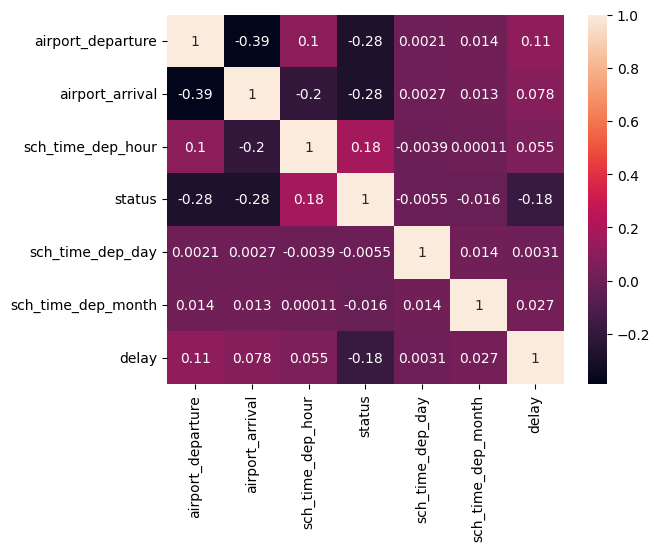

In [147]:
sns.heatmap(data=df_delayed_flights[["airport_departure", "airport_arrival", "sch_time_dep_hour", "status", "sch_time_dep_day", "sch_time_dep_month", "delay"]].corr(), annot=True)

## Train test split

In [148]:
columns_to_scale = ["airport_departure", "airport_arrival", "sch_time_dep_hour", "sch_time_dep_day", "sch_time_dep_month",  "status"]

X = df_delayed_flights[columns_to_scale]
y = df_delayed_flights["delay"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RSEED)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

## Baseline model

All flights with departure time between 7 am and 10 am have a delay, as we assume that in the morning rush hour there will be a lot of flights leaving and this will have a negative influence on the punctuality.

In [149]:
def baseline_model(row):
    
    dep_hour = row['sch_time_dep_hour']
    
    if 7>= dep_hour <= 10:
        return '15 min delay'
    else:
        return 'No delay'
    
# Apply baseline model to each row in the DataFrame
y_test_pred_baseline = df_test.apply(baseline_model, axis=1)

In [150]:
# Create the baseline model
X_base = df_test["sch_time_dep_hour"]
y_base = df_test["delay"]

In [151]:
# Predict the percentage of delayed flights in the morning between 7 am and 10 am
df_base = df_test[(df_test["sch_time_dep_hour"] >= 7) & (df_test["sch_time_dep_hour"]<= 10)]

all_observations = len(df_base)
no_observations = len(df_base[df_base["delay"] > 0.0])

percent_of_flights_with_delay = no_observations * 100 / all_observations
round(percent_of_flights_with_delay, 1)

65.1

## Using the standard scaler

In [152]:
scaler = StandardScaler()

# Fit & Transform: Calculate mean/standard deviation und transform
df_delayed_flights[columns_to_scale] = scaler.fit_transform(df_delayed_flights[columns_to_scale])

# Important: apply only .transform() on the test set, not fit !!!
df_delayed_flights[columns_to_scale] = scaler.transform(df_delayed_flights[columns_to_scale])

## Linear Regression model

In [153]:
lin_reg = LinearRegression().fit(X_train, y_train)

y_pred_test = lin_reg.predict(X_test)